In [41]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [42]:
%load_ext autoreload
%autoreload 1
%aimport cowaver.utils
%aimport cowaver.datasets
%aimport cowaver.datamodules
%aimport cowaver.models
%aimport cowaver.modules
%aimport cowaver.checkpoints
%aimport cowaver.transforms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Constantes

In [43]:
from pathlib import Path

# Rutas a los datos
# tiny_emnist_filename = Path("../data/tiny-emnist-26.tar.xz")
# tiny_kalulu_filename = Path("../data/tiny-kalulu-200.tar.xz")
tiny_phones_filename = Path("../tiny-phones-200.tar.xz")
tiny_letter_filename = Path("../tiny-letter-30.tar.xz")
# kalulu_words_filename = Path("../data/kalulu-words.tar.xz")
# kalulu_phonemes_filename = Path("../data/kalulu-phonemes.tar.xz")
mswc_microset_filename = Path("../tiny-mswc-200.tar.xz")

data_path = Path("../data")  # Carpeta donde se descomprimirán los datos
checkpoints_path = Path("../checkpoints")

num_layers_in_wav2vec2 = 12

### Funciones utilitarias

### Funciones de graficado

In [44]:
import io
import ipywidgets as widgets
import torchaudio
import torch
import matplotlib.pyplot as plt
import numpy as np
from cowaver.utils import AUDIO_SAMPLE_RATE
from cowaver.models import TrainHistory, TestResults

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

def plot_waveform(waveform, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if waveform.dim() == 2:
        waveform = waveform[0]

    waveform = waveform.detach().cpu()
    time = torch.arange(len(waveform)) / AUDIO_SAMPLE_RATE

    ax.plot(time.numpy(), waveform.numpy())
    ax.set_title("Forma de onda")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    if should_show:
        plt.show()

def plot_image(image, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if image.dim() == 5:
        image = image[0, 0]      # [S,B,C,H,W] -> primera imagen
    elif image.dim() == 4:
        image = image[0]         # [B,C,H,W] -> primera imagen
    elif image.dim() != 3:
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image.detach().cpu()

    ax.imshow(image.clamp(0, 1).permute(1, 2, 0))
    ax.set_title("Imagen")
    # ax.axis("off")

    if should_show:
        plt.show()

def plot_train_history(train_history: TrainHistory, subfig=None):
    if subfig is None:
        _, ax = plt.subplots(figsize=(8, 3), layout="constrained")
        should_show = True
    else:
        ax = subfig.subplots()
        should_show = False
    epochs = range(1, train_history.num_epochs + 1)
    ax.plot(epochs, train_history.train_losses, label="Entrenamiento")
    ax.plot(epochs, train_history.val_losses, "r", label="Validación")
    ax.set_title("Training vs Validation Loss")
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    if should_show:
        plt.show()

def plot_logits(logits, classes, subfig=None):
    if subfig is None:
        fig = plt.figure(figsize=(8, 3), layout="constrained")
        subfig = fig.subfigures()
        should_show = True
    else:
        should_show = False

    topk_values, topk_indices = torch.topk(logits.detach().cpu().squeeze(), k=5)
    topk_classes = [classes[i] for i in topk_indices.cpu().numpy()]

    logits, classes = topk_values, topk_classes
    
    values = logits.squeeze().numpy()
    order = np.argsort(values)[::-1]
    sorted_classes  = [classes[i] for i in order]
    sorted_values = values[order]

    ax = subfig.subplots()
    ax.plot(sorted_classes, sorted_values, marker='o')
    ax.set_title("Logits")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    if should_show:
        plt.show()

def plot_test_results(test_results: TestResults | list):
    plt.figure(figsize=(10, 3), layout="constrained")
    if isinstance(test_results, TestResults):
        plt.bar(["top1", "top3", "top5"], [test_results.top1, test_results.top3, test_results.top5])
    else:
        plt.plot(range(len(test_results)), list(map(lambda x: x.top1, test_results)), 'r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top3, test_results)), '--r')
        plt.plot(range(len(test_results)), list(map(lambda x: x.top5, test_results)), ':r')
        plt.legend(["top1", "top3", "top5"])
    plt.ylim(0.0, 1.0)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

def plot_activation(activation, ax=None, vmin=-3, vmax=3):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if activation.dim() == 4:
        activation = activation[0, 0]
    elif activation.dim() == 3:
        activation = activation[0]
    elif activation.dim() != 2:
        raise ValueError(f"Unexpected activation shape: {activation.shape}")

    activation = activation.detach().cpu()

    im = ax.imshow(
        activation.numpy(),
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_title("Activación")
    ax.set_xlabel("Dimensión")
    ax.set_ylabel("Ventana")
    ax.set_xticks([0, activation.size(1) - 1])
    ax.set_yticks([0, activation.size(0) - 1])

    if should_show:
        plt.colorbar(im, ax=ax)
        plt.show()

    return im
        
def plot_mel(mel, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if mel.dim() == 4:
        mel = mel[0, 0]       # [B,1,mel_bins,T]
    elif mel.dim() == 3:
        mel = mel[0]          # [B,mel_bins,T] o [1,mel_bins,T]
    elif mel.dim() != 2:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    mel = torch.expm1(mel).clamp_min(0)
    mel = mel.detach().cpu()

    ax.imshow(
        mel.numpy(),
        cmap="coolwarm",
        aspect="auto"
    )

    ax.set_title("Mel")
    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Mel bins")
    ax.set_xticks([0, mel.size(1) - 1])
    ax.set_yticks([0, mel.size(0) - 1])

    if should_show:
        plt.show()


def plot_pca(scores: torch.Tensor, labels: list | None):
    """Grafica una proyección PCA bidimensional.

    Parameters
    ----------
    scores: Tensor
        Tensor de forma [B, q], donde B es el número de ejemplos.
        Se grafican las dos primeras componentes.

    labels: list | None
        Lista opcional de etiquetas, una por ejemplo. Si se proporciona,
        debe tener largo B.
    """
    
    scores = scores.detach().cpu()

    if labels is not None and len(labels) != scores.size(0):
        raise ValueError("labels debe tener el mismo largo que scores.")
    
    plt.figure(figsize=(6, 6))
    plt.scatter(scores[:, 0], scores[:, 1])
    if labels is not None:
        for i, label in enumerate(labels):
            plt.text(scores[i, 0].item(), scores[i, 1].item(), label, fontsize=9)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA")
    plt.grid(True)
    plt.show()

## Preparación del entorno

In [5]:
from cowaver.utils import descomprimir_archivo

# tiny_emnist_path = descomprimir_archivo(tiny_emnist_filename, data_path)
# tiny_kalulu_path = descomprimir_archivo(tiny_kalulu_filename, data_path)
tiny_phones_path = descomprimir_archivo(tiny_phones_filename, data_path)
tiny_letter_path = descomprimir_archivo(tiny_letter_filename, data_path)
# kalulu_words_path = descomprimir_archivo(kalulu_words_filename, data_path)
# kalulu_phonemes_path = descomprimir_archivo(kalulu_phonemes_filename, data_path)
mswc_microset_path = descomprimir_archivo(mswc_microset_filename, data_path)

Descomprimiendo ../tiny-phones-200.tar.xz en ../data/tiny-phones-200... OK
Descomprimiendo ../tiny-letter-30.tar.xz en ../data/tiny-letter-30... YA EXISTE
Descomprimiendo ../tiny-mswc-200.tar.xz en ../data/tiny-mswc-200... OK


## Conjuntos de datos

### TinyMel

In [45]:
from cowaver.datamodules import TinyMel
from cowaver.datasets import TinySpeakDataset, ImageMelDataset
from cowaver.transforms import RandomAlign
from cowaver.utils import explorar_datos, extraer_waveform

letters_data = TinyMel(tiny_letter_path, mel_bins=80)

def explore_tiny_mel(data, batch):
    (image, mel), label = batch
    fig = plt.figure(figsize=(9, 3), layout="constrained")
    axes = fig.subplot_mosaic([["image", "mel"]], gridspec_kw={"width_ratios": [1, 2]})
    plot_image(image, axes["image"])
    plot_mel(mel, axes["mel"])
    fig.suptitle(data.classes[label.item()])
    plt.show()

    waveform = extraer_waveform(mel[0])
    display(audio_widget(waveform[0]))

explorar_datos(letters_data, explore_tiny_mel)

In [46]:
phones_data = TinyMel(tiny_phones_path, mel_bins=80)
explorar_datos(phones_data, explore_tiny_mel)

In [47]:
words_data = TinyMel(mswc_microset_path, mel_bins=80)
explorar_datos(words_data, explore_tiny_mel)

## Features

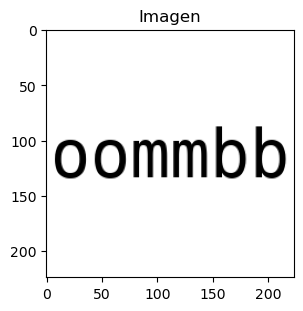

torch.Size([1, 3, 224, 224])
torch.Size([1, 256, 14, 14])
torch.Size([1, 24, 256])


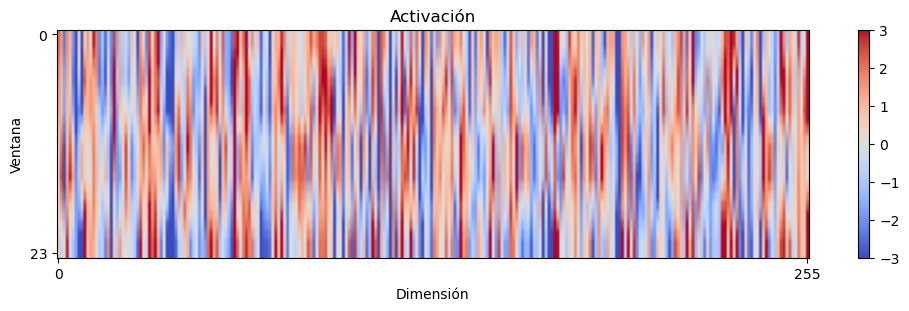

In [68]:
from torch import nn
from cowaver.utils import make_image
from cowaver.modules.cornet import CORnet_Z
from cowaver.modules.unconditioned import ImageToHorizontalFeatures

image = make_image("oommbb").unsqueeze(0)

plot_image(image)

cornet_z = CORnet_Z()
cornet_z.module.IT = nn.Identity()
cornet_z.module.decoder = nn.Identity()

print(image.shape)
cornet_features = cornet_z(image)
print(cornet_features.shape)
# plot_activation(cornet_features)

visual_encoder = ImageToHorizontalFeatures()
encoded_features = visual_encoder(image)
print(encoded_features.shape)
plot_activation(encoded_features)

## CoWaver

In [19]:
from cowaver.modules import build_model, MODEL_REGISTRY, DECODER_REGISTRY, TEMPORAL_ADAPTER_REGISTRY
from cowaver.checkpoints import cargar_checkpoint

architecture = 'unconditioned'
print("Arquitectura:", architecture)
print("Arquitecturas disponibles:", list(MODEL_REGISTRY.keys()))

adapter = 'convolutional'
print("Adapter:", adapter)
print("Adapters disponibles:", list(TEMPORAL_ADAPTER_REGISTRY.keys()))

decoder = 'convolutional'
print("Decodificador:", decoder)
print("Decodificadores disponibles:", list(DECODER_REGISTRY.keys()))

cowaver = build_model(architecture, latent_dim=256, hidden_size=256, mel_bins=80, width_steps=24, adapter=adapter, decoder=decoder)
train_history = cargar_checkpoint(cowaver, folder=checkpoints_path)

#for i in range(3):
#        train_histories.append(cargar_checkpoint(cowaver, phase=i+1, folder=checkpoints_path))
#train_history = TrainHistory(
#    train_losses=list(itertools.chain.from_iterable(x.train_losses for x in train_histories)),
#    val_losses=list(itertools.chain.from_iterable(x.val_losses for x in train_histories))
#)

Arquitectura: unconditioned
Arquitecturas disponibles: ['unconditioned', 'dual-route', 'conditioned']
Adapter: convolutional
Adapters disponibles: ['convolutional', 'recurrent', 'transformer']
Decodificador: convolutional
Decodificadores disponibles: ['convolutional', 'recurrent', 'transformer', 'upsampling']
Red cowaver_lt256_hs256_sl49_mb80_ws24 | fase 3
Epoch 1/30 | train_loss=0.7334 | val_loss=1.1453
Epoch 2/30 | train_loss=0.6904 | val_loss=1.1437
Epoch 3/30 | train_loss=0.7067 | val_loss=1.1475
Epoch 4/30 | train_loss=0.6791 | val_loss=1.1383
Epoch 5/30 | train_loss=0.6946 | val_loss=1.1442
Epoch 6/30 | train_loss=0.6814 | val_loss=1.1430
Epoch 7/30 | train_loss=0.7018 | val_loss=1.1377
Epoch 8/30 | train_loss=0.6782 | val_loss=1.1396
Epoch 9/30 | train_loss=0.6772 | val_loss=1.1402
Epoch 10/30 | train_loss=0.6899 | val_loss=1.1447
Epoch 11/30 | train_loss=0.6676 | val_loss=1.1384
Epoch 12/30 | train_loss=0.6846 | val_loss=1.1377
Epoch 13/30 | train_loss=0.6612 | val_loss=1.1420


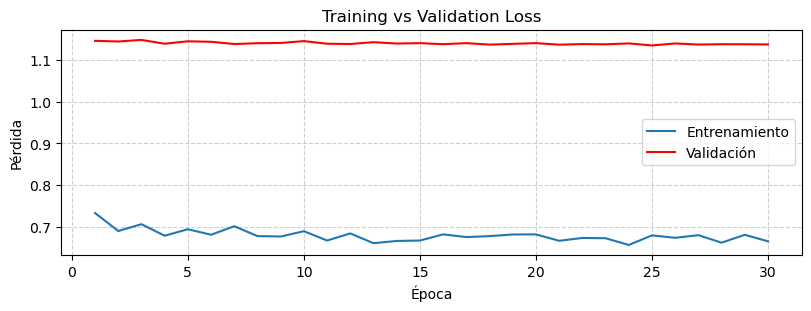

In [20]:
plot_train_history(train_history)

In [21]:
from cowaver.utils import explorar_red, extraer_waveform, AUDIO_SAMPLE_RATE

def explore_cowaver(net, batch):
    (x, y), _ = batch
    y_hat, z = net(x)
    
    fig = plt.figure(figsize=(9, 7), layout="constrained")
    axes = fig.subplot_mosaic([["x", "y"], ["z", "y_hat"]], gridspec_kw={"width_ratios": [1, 2]})
    
    plot_image(x.cpu(), ax=axes["x"])
    plot_mel(y.cpu(), ax=axes["y"])
    plot_activation(z, ax=axes["z"])
    plot_mel(y_hat.cpu(), ax=axes["y_hat"])
    
    plt.show()

    waveform = extraer_waveform(y_hat.cpu())
    display(audio_widget(extraer_waveform(y.cpu())[0]))
    display(audio_widget(waveform[0]))

letters_data = TinyMel(tiny_letter_path, mel_bins=cowaver.mel_bins)
explorar_red(cowaver, letters_data, explore_cowaver)

In [22]:
words_data = TinyMel(tiny_phones_path, mel_bins=cowaver.mel_bins)
explorar_red(cowaver, words_data, explore_cowaver)

In [23]:
mswc_microset_data = TinyMel(mswc_microset_path, mel_bins=cowaver.mel_bins)
explorar_red(cowaver, mswc_microset_data, explore_cowaver)

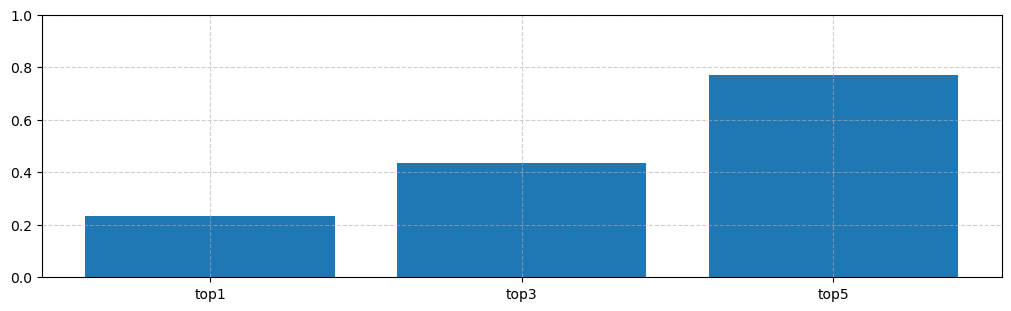

In [24]:
from cowaver.utils import evaluar_red

letters_data = TinyMel(tiny_letter_path, mel_bins=cowaver.mel_bins)
test_results = evaluar_red(cowaver, letters_data)
plot_test_results(test_results)

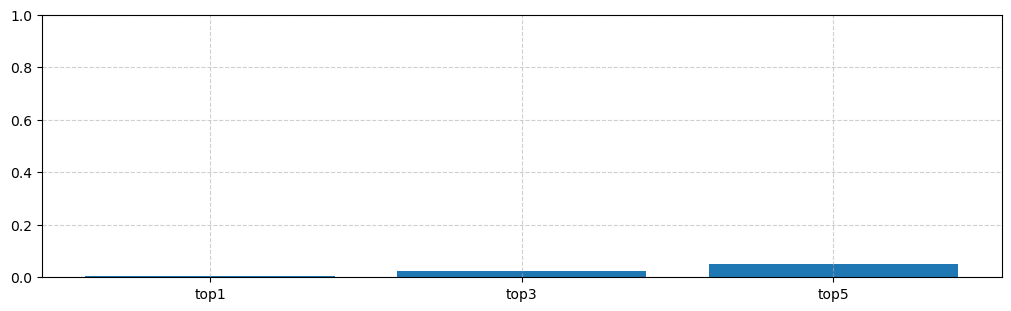

In [25]:
words_data = TinyMel(tiny_phones_path, mel_bins=cowaver.mel_bins)
test_results = evaluar_red(cowaver, words_data)
plot_test_results(test_results)

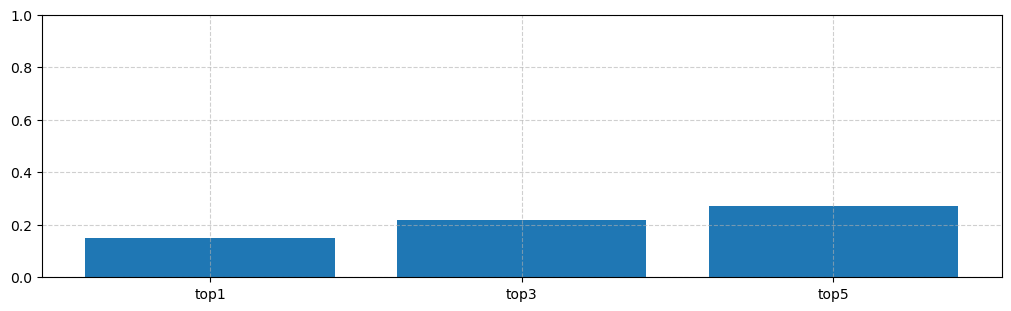

In [26]:
mswc_microset_data = TinyMel(mswc_microset_path, mel_bins=cowaver.mel_bins)
test_results = evaluar_red(cowaver, mswc_microset_data)
plot_test_results(test_results)

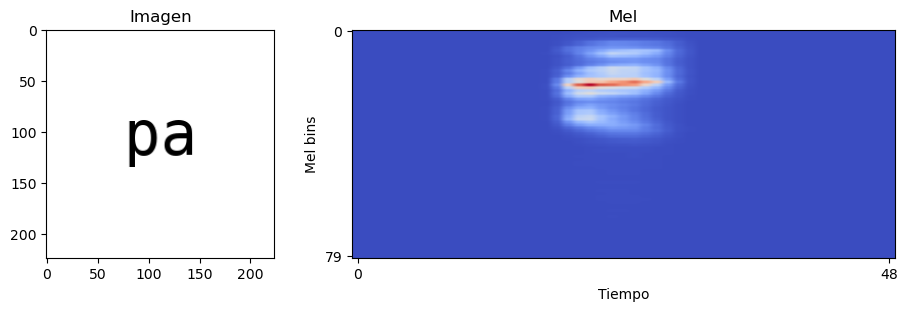

Audio(value=b'RIFF\x88\xf5\x00\x00WAVEfmt \x10\x00\x00\x00\x03\x00\x01\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x0…

In [36]:
from cowaver.utils import make_image

x = make_image("pa")
with torch.no_grad():
    x = x.to(torch.device("cpu"))
    cowaver = cowaver.to(torch.device("cpu"))
    y_hat, z = cowaver(x)
    waveform = extraer_waveform(y_hat)
    
    fig = plt.figure(figsize=(9, 3), layout="constrained")
    axes = fig.subplot_mosaic([["x", "y_hat"]], gridspec_kw={"width_ratios": [1, 2]})
    
    plot_image(x, ax=axes["x"])
    plot_mel(y_hat.cpu(), ax=axes["y_hat"])
    
    plt.show()

    display(audio_widget(waveform[0]))

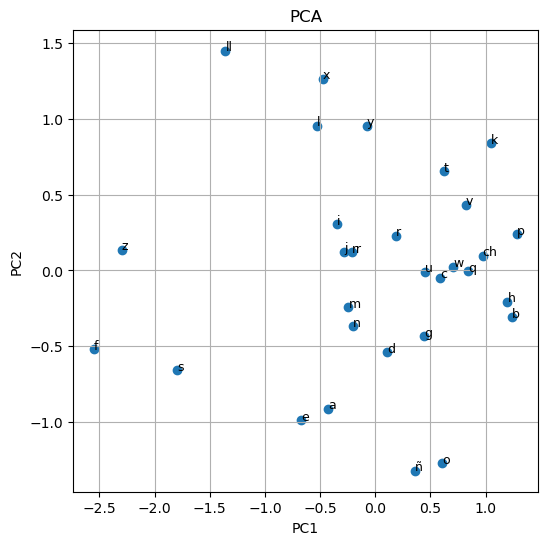

In [40]:
from cowaver.utils import make_image, pca

def pca_analysis(net, dataset: TinySpeakDataset):
    words = dataset.words
    
    xs = []
    for word in words:
        x = make_image(word)
        xs.append(x)
    
    X = torch.stack(xs, dim=0)
    
    with torch.no_grad():
        y_hat, z = net(X)
    
    torch.manual_seed(42)
    X_scores = pca(z.mean(dim=1))
    plot_pca(X_scores, words)

pca_analysis(cowaver, TinySpeakDataset(base_dir=tiny_letter_path / "train"))

In [25]:
pca_analysis(cowaver, TinySpeakDataset(base_dir=tiny_swbc_path / "train"))

NameError: name 'tiny_swbc_path' is not defined